In [56]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
from astropy.io import fits
from matplotlib import pyplot as plt

#from pipeline_config import MAPS_DIR

In [57]:
datasets = [
     {
        "instrument": "MUSE",
        "line": "Halpha",
        "filename": "MUSE-M42-H-bin4_trim.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "MUSE",
        "line": "NII_6583",
        "filename": "MUSE-M42-N-bin4_trim.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "MUSE",
        "line": "OIII_5007",
        "filename": "MUSE-M42-O-bin4_trim.fits",
        "label": r"[O III] $\lambda$5007",
    },
    {
        "instrument": "MUSE",
        "line": "Halpha",
        "filename": "MUSE-M42-H-bin4.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "MUSE",
        "line": "NII_6583",
        "filename": "MUSE-M42-N-bin4.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "MUSE",
        "line": "OIII_5007",
        "filename": "MUSE-M42-O-bin4.fits",
        "label": r"[O III] $\lambda$5007",
    },
    {
        "instrument": "KPNO",
        "line": "Halpha",
        "filename": "KPNO-M42-H-bin2.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "KPNO",
        "line": "NII_6583",
        "filename": "KPNO-M42-N-bin2.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "KPNO",
        "line": "OIII_5007",
        "filename": "KPNO-M42-O-bin2.fits",
        "label": r"[O III] $\lambda$5007",
    },
]

In [93]:
def load_velocity_dataset(entry):
    fits_path = entry["filename"]

    with fits.open(fits_path) as hdul:
        sb = hdul["MOM0"].data.astype(float)
        vv = hdul["MOM1"].data.astype(float)
#        mask = hdul["MASK"].data.astype(bool)

    #sb = np.where(mask, sb, np.nan)
    #vv = np.where(mask, vv, np.nan)

    df = pd.DataFrame({
        "X": np.indices(vv.shape)[0].ravel(),
        "Y": np.indices(vv.shape)[1].ravel(),
        "VV": vv.ravel(),
        "SB": sb.ravel(),
 #       "mask": mask.ravel(),
    })

    df = df.dropna(subset=["VV"])

    df["instrument"] = entry["instrument"]
    df["line"] = entry["line"]
    df["label"] = entry["label"]
    df["filename"] = entry["filename"]

    mean_v = df["VV"].mean()
    df["RV_centered"] = df["VV"] - mean_v

    raw = {
        "sb": sb,
        "vv": vv,
 #       "mask": mask,
        "instrument": entry["instrument"],
        "line": entry["line"],
        "label": entry["label"],
        "filename": entry["filename"],
    }

    return df, raw

In [94]:
processed_list = []
raw_data = {}

for entry in datasets:
    df, raw = load_velocity_dataset(entry)
    processed_list.append(df)

    key = (entry["line"], entry["instrument"])
    raw_data[key] = raw

processed_data = pd.concat(processed_list, ignore_index=True)

In [95]:
processed_data.head()

,X,Y,VV,SB,instrument,line,label,filename,RV_centered
0,0,0,12.569437,0.093462,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.861730
1,0,1,12.634685,0.094589,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.796482
2,0,2,12.721270,0.093625,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.709897
3,0,3,12.816681,0.099161,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.614486
4,0,4,13.425719,0.101606,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.005448


In [96]:
processed_data.groupby(["line", "instrument"])["VV"].describe()

count       mean       std       min        25%  \
line      instrument                                                       
Halpha    KPNO         11264.0  16.790019  3.047269 -4.438542  15.030875   
          MUSE         14965.0  14.050310  2.581294  5.070816  12.575871   
NII_6583  KPNO        182115.0  20.526852  2.762730  9.205535  18.640390   
          MUSE         14965.0  17.204750  2.647849  0.330185  15.488735   
OIII_5007 KPNO        182115.0  16.270836  2.745423  6.216364  14.694619   
          MUSE         14965.0  10.557590  2.468254  0.112902   9.318898   

                            50%        75%        max  
line      instrument                                   
Halpha    KPNO        17.241138  18.860740  23.812250  
          MUSE        13.867973  15.602428  22.998160  
NII_6583  KPNO        20.262312  21.940784  31.288391  
          MUSE        16.963535  18.690324  27.934929  
OIII_5007 KPNO        16.101160  18.018742  25.508438  
          MUSE        10.441826  11.928051  20.832185

In [97]:
processed_data

,X,Y,VV,SB,instrument,line,label,filename,RV_centered
0,0,0,12.569437,0.093462,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.861730
1,0,1,12.634685,0.094589,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.796482
2,0,2,12.721270,0.093625,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.709897
3,0,3,12.816681,0.099161,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.614486
4,0,4,13.425719,0.101606,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin4_trim.fits,-1.005448
...,...,...,...,...,...,...,...,...,...
420384,512,350,14.285112,0.116082,KPNO,OIII_5007,[O III] $\lambda$5007,KPNO-M42-O-bin2.fits,-1.985724
420385,512,351,14.260201,0.114906,KPNO,OIII_5007,[O III] $\lambda$5007,KPNO-M42-O-bin2.fits,-2.010635
420386,512,352,14.235290,0.113731,KPNO,OIII_5007,[O III] $\lambda$5007,KPNO-M42-O-bin2.fits,-2.035547
420387,512,353,16.062177,0.000000,KPNO,OIII_5007,[O III] $\lambda$5007,KPNO-M42-O-bin2.fits,-0.208660


In [98]:
instrument_colors = {
    "MUSE": "black",
    "KPNO": "darkgray",
}

line_order = [
    "Halpha",
    "NII_6583",
    "OIII_5007",
    "SIII_9069",
    "SII_6731",
    "ArIII_7136",
]

In [99]:
ha_muse_trim = processed_data[
    (processed_data["filename"] == "MUSE-M42-H-bin4_trim.fits")
]

In [100]:
ha_muse_trim = processed_data[
    (processed_data["filename"] == "MUSE-M42-H-bin4_trim.fits")
]

In [101]:
ha_kpno = processed_data[
    (processed_data["filename"] == "KPNO-M42-H-bin2.fits")
]

C:\Users\javas\anaconda3\envs\viento\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


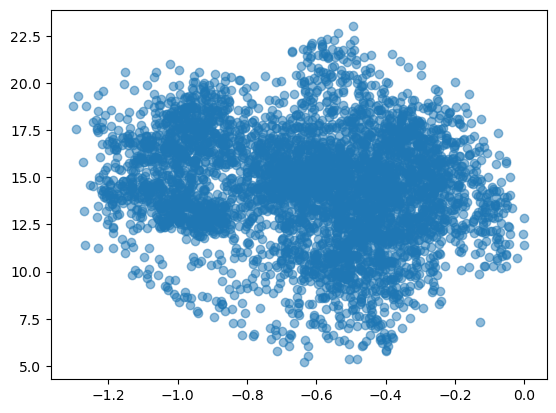

In [102]:
plt.scatter(np.log10(ha_muse_trim.SB), ha_muse_trim.VV, alpha = 0.5)

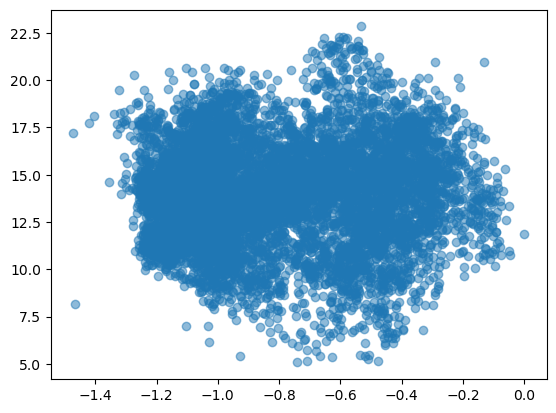

In [103]:
plt.scatter(np.log10(ha_muse.SB), ha_muse.VV, alpha = 0.5)

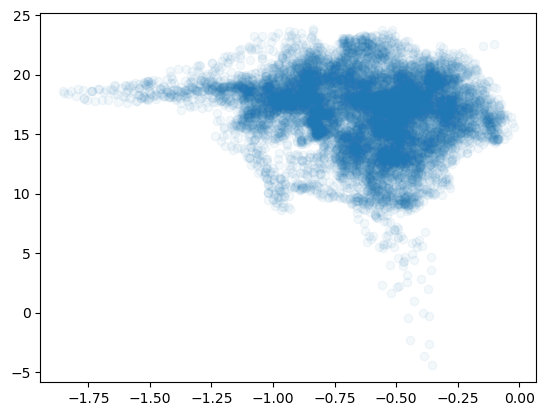

In [104]:
plt.scatter(np.log10(ha_kpno.SB), ha_kpno.VV, alpha = 0.05)